In [ ]:
# Exercise 6 - Part 1

# Number of busy lines in a trunk group (Erlang system) follows a Poisson distribution P(i)=c*(A^i/i!), i = 0,...,m.
# Generate samples from this distribution using the Metropolis-Hastrings algorithm. 
# Verify the distribution using chi-square goodness-of-fit-test. 


True probabilities: [0.00041116 0.00328931 0.01315724 0.03508597 0.07017194 0.1122751
 0.14970014 0.17108587 0.17108587 0.15207633 0.12166106]
Empirical probabilities: [1.000e-04 3.600e-03 1.390e-02 4.030e-02 7.920e-02 1.229e-01 1.591e-01
 1.800e-01 1.763e-01 1.594e-01 6.520e-02]
Chi-square statistic: 310.1759791988641
p-value: 1.0952581017393204e-60


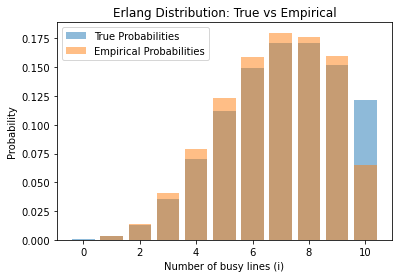

In [ ]:
import numpy as np
from scipy.stats import chisquare
from math import factorial
import matplotlib.pyplot as plt

# The idea is, that after running long enough, the distribution of samples will approximate the true Erlang distribution, 
# and we can compare the empirical frequencies with the true probabilities using a chi-square test.

# Erlang distribution probabilities
def erlang_probs(A, m):
    unnorm = np.array([A**i / factorial(i) for i in range(m+1)])
    return unnorm / unnorm.sum()

# Metropolis-Hastings sampling for Erlang distribution; move to i+1 or i-1 with equal probability
def mh_sample_erlang(A, m, n_samples):
    P = erlang_probs(A, m)
    samples = np.zeros(n_samples, dtype=int)

    x = np.random.randint(0, m+1)   # initial state

    for t in range(n_samples):
        # propose neighbor
        if x == 0:
            y = 1
        elif x == m:
            y = m-1
        else:
            y = x + np.random.choice([-1, 1])

        # acceptance probability
        alpha = min(1, P[y] / P[x])

        if np.random.rand() < alpha:
            x = y

        samples[t] = x

    return samples, P


A = 8
m = 10
n_samples = 10000

samples, true_probs = mh_sample_erlang(A, m, n_samples)

# empirical frequencies
counts = np.bincount(samples, minlength=m+1)
empirical_probs = counts / n_samples


expected_counts = true_probs * n_samples
chi2_stat, p_value = chisquare(counts, expected_counts)

print("True probabilities:", true_probs)
print("Empirical probabilities:", empirical_probs)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

# Plot of results
plt.bar(range(m+1), true_probs, alpha=0.5, label='True Probabilities')
plt.bar(range(m+1), empirical_probs, alpha=0.5, label='Empirical Probabilities')
plt.xlabel('Number of busy lines (i)')
plt.ylabel('Probability')
plt.title('Erlang Distribution: True vs Empirical')
plt.legend()
plt.show()

In [ ]:
# Exercise 6 - Part 2

import numpy as np
from scipy.special import factorial
from scipy.stats import chi2


A1 = 4
A2 = 4
m = 10

# All valid states: i >= 0, j >= 0, i + j <= m
states = [(i, j) for i in range(m + 1) for j in range(m + 1 - i)]
state_to_idx = {s: k for k, s in enumerate(states)}
n_states = len(states)

# Theoretical probabilities
weights = np.array([
    A1**i / factorial(i) * A2**j / factorial(j)
    for i, j in states
])

probs = weights / weights.sum()

# Helper functions

def valid(i, j):
    """Check whether (i,j) is a valid state."""
    return i >= 0 and j >= 0 and i + j <= m


def target_weight(i, j):
    """Unnormalised target probability."""
    if not valid(i, j):
        return 0
    return A1**i / factorial(i) * A2**j / factorial(j)


def target_ratio(new_i, new_j, old_i, old_j):
    """Ratio pi(new) / pi(old)."""
    return target_weight(new_i, new_j) / target_weight(old_i, old_j)


def sample_truncated_poisson(lam, max_value):
    """Sample from Poisson(lam), truncated to 0,...,max_value."""
    values = np.arange(max_value + 1)
    p = lam**values / factorial(values)
    p = p / p.sum()
    return np.random.choice(values, p=p)


# (a) Direct Metropolis-Hastings

def direct_mh(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples = []
    accepted = 0
    proposed = 0

    for step in range(burn_in + n_samples * thin):

        # Propose one of four neighbouring states
        move = np.random.randint(4)

        if move == 0:
            i_new, j_new = i + 1, j
        elif move == 1:
            i_new, j_new = i - 1, j
        elif move == 2:
            i_new, j_new = i, j + 1
        else:
            i_new, j_new = i, j - 1

        proposed += 1

        # Invalid proposals are rejected automatically
        if valid(i_new, j_new):
            alpha = min(1, target_ratio(i_new, j_new, i, j))

            if np.random.rand() < alpha:
                i, j = i_new, j_new
                accepted += 1

        # Save after burn-in and thinning
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))

    return np.array(samples), accepted / proposed


# (b) Coordinate-wise Metropolis-Hastings


def coordinate_mh(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples = []

    accepted_i = accepted_j = 0
    proposed_i = proposed_j = 0

    for step in range(burn_in + n_samples * thin):

        # Update i while keeping j fixed
        i_new = i + np.random.choice([-1, 1])
        proposed_i += 1

        if valid(i_new, j):
            alpha = min(1, target_ratio(i_new, j, i, j))

            if np.random.rand() < alpha:
                i = i_new
                accepted_i += 1

        # Update j while keeping i fixed
        j_new = j + np.random.choice([-1, 1])
        proposed_j += 1

        if valid(i, j_new):
            alpha = min(1, target_ratio(i, j_new, i, j))

            if np.random.rand() < alpha:
                j = j_new
                accepted_j += 1

        # Save after burn-in and thinning
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))

    acc_i = accepted_i / proposed_i
    acc_j = accepted_j / proposed_j

    return np.array(samples), (acc_i, acc_j)



# (c) Gibbs sampling


def gibbs_sampler(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples = []

    for step in range(burn_in + n_samples * thin):

        # Conditional distribution:
        # i | j is Poisson(A1), truncated to 0,...,m-j
        i = sample_truncated_poisson(A1, m - j)

        # Conditional distribution:
        # j | i is Poisson(A2), truncated to 0,...,m-i
        j = sample_truncated_poisson(A2, m - i)

        # Save after burn-in and thinning
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))

    return np.array(samples)



# Chi-square test

def chi_square_test(samples):
    n = len(samples)

    # Observed counts
    observed = np.zeros(n_states)

    for s in samples:
        observed[state_to_idx[tuple(s)]] += 1

    # Expected counts under the theoretical distribution
    expected = n * probs

    # Chi-square statistic
    stat = np.sum((observed - expected)**2 / expected)

    # Degrees of freedom: number of categories - 1
    df = n_states - 1

    # p-value
    p_value = 1 - chi2.cdf(stat, df)

    return stat, df, p_value



# Run 

np.random.seed(42)

n_samples = 20000
burn_in = 5000
thin = 5

samples_a, acc_a = direct_mh(n_samples, burn_in, thin)
samples_b, acc_b = coordinate_mh(n_samples, burn_in, thin)
samples_c = gibbs_sampler(n_samples, burn_in, thin)

print("Acceptance rates")
print("----------------")
print(f"Direct MH:        {acc_a:.3f}")
print(f"Coordinate MH i:  {acc_b[0]:.3f}")
print(f"Coordinate MH j:  {acc_b[1]:.3f}")

print("\nChi-square tests")
print("----------------")

for name, samples in [
    ("Direct MH", samples_a),
    ("Coordinate-wise MH", samples_b),
    ("Gibbs sampling", samples_c)
]:
    stat, df, p = chi_square_test(samples)

    print(f"\n{name}")
    print(f"chi2 statistic = {stat:.3f}")
    print(f"df             = {df}")
    print(f"p-value        = {p:.4f}")

Acceptance rates
----------------
Direct MH:        0.764
Coordinate MH i:  0.767
Coordinate MH j:  0.766

Chi-square tests
----------------

Direct MH
chi2 statistic = 85.459
df             = 65
p-value        = 0.0454

Coordinate-wise MH
chi2 statistic = 71.323
df             = 65
p-value        = 0.2757

Gibbs sampling
chi2 statistic = 49.118
df             = 65
p-value        = 0.9287


In [2]:
# Exercise 6 - Part 3

In [3]:
#(a)

import numpy as np
from scipy import stats

rho = 0.5

mu = np.array([0, 0])

cov_mat = np.array([
    [1,   rho],
    [rho, 1]
])

# Generate one sample from (Xi, Gamma)

np.random.seed(43)

xi, gamma = stats.multivariate_normal.rvs(
    mean=mu,
    cov=cov_mat
)


# Transform to get one sample from (Theta, Psi)
# Since Xi = log(Theta), we have Theta = exp(Xi)
# Since Gamma = log(Psi), we have Psi = exp(Gamma)


theta = np.exp(xi)
psi = np.exp(gamma)


print(f"xi     = {xi:.4f}")
print(f"gamma  = {gamma:.4f}")

print(f"theta  = {theta:.4f}")
print(f"psi    = {psi:.4f}")

xi     = 0.2313
gamma  = -0.6772
theta  = 1.2603
psi    = 0.5081


In [4]:
# (b)
import numpy as np
from scipy import stats

# Prior parameters for (Xi, Gamma) = (log(Theta), log(Psi))
rho = 0.5

mu = np.array([0, 0])

cov_mat = np.array([
    [1,   rho],
    [rho, 1]
])

# Generate one sample from the prior

np.random.seed(43)

xi, gamma = stats.multivariate_normal.rvs(
    mean=mu,
    cov=cov_mat
)

# Transform back to get theta and psi
theta = np.exp(xi)
psi = np.exp(gamma)

print("Generated parameter values:")
print(f"theta = {theta:.4f}")
print(f"psi   = {psi:.4f}")

# Simulate observations X_1, ..., X_n


n = 10

# Since X_i - N(theta, psi), psi is the variance.
# np.random.normal uses standard deviation, so we use sqrt(psi).
X = np.random.normal(
    loc=theta,
    scale=np.sqrt(psi),
    size=n
)

print("\nSimulated observations:")
print(X)

Generated parameter values:
theta = 1.2603
psi   = 0.5081

Simulated observations:
[0.99047912 0.8789909  1.8718902  0.96588319 1.61537034 2.69310633
 2.16041647 0.9472048  1.01333467 1.58481408]



Posterior sampling for n = 10
Acceptance rate: 0.6321
Posterior mean theta: 1.1509
Posterior mean psi:   1.0614
95% interval theta:   [0.55801969 1.80645102]
95% interval psi:     [0.44865933 2.29930412]
True theta:           1.2603
True psi:             0.5081

Posterior sampling for n = 100
Acceptance rate: 0.4930
Posterior mean theta: 1.1903
Posterior mean psi:   0.5361
95% interval theta:   [1.0444742  1.34157292]
95% interval psi:     [0.40723246 0.70920421]
True theta:           1.2603
True psi:             0.5081

Posterior sampling for n = 1000
Acceptance rate: 0.3842
Posterior mean theta: 1.2530
Posterior mean psi:   0.5127
95% interval theta:   [1.20844624 1.29693263]
95% interval psi:     [0.46802797 0.56100427]
True theta:           1.2603
True psi:             0.5081


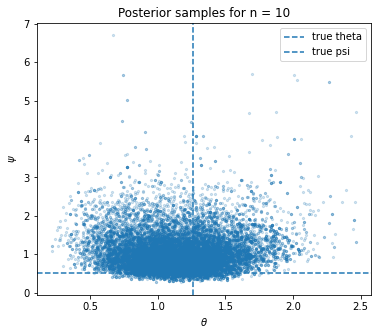

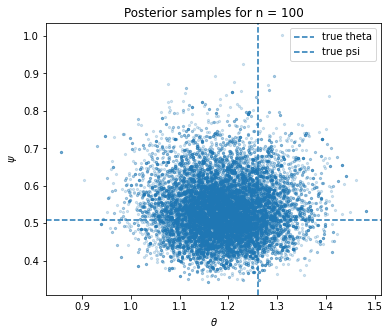

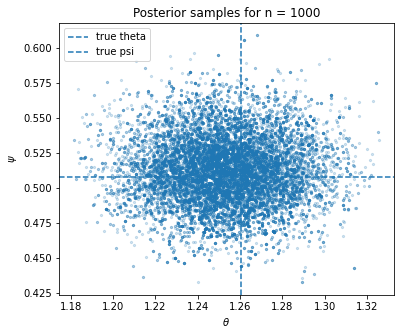

In [ ]:
# (c) + (d) + (e) 

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

theta_true = theta
psi_true = psi

rho = 0.5

mu = np.array([0, 0])
cov_mat = np.array([
    [1,   rho],
    [rho, 1]
])


# Generate data once with n = 1000
# Then reuse the first 10, 100, and 1000 observations


np.random.seed(44)

X_all = np.random.normal(
    loc=theta_true,
    scale=np.sqrt(psi_true),
    size=1000
)

# (c): posterior density, implemented in log scale


def log_posterior_logparams(xi, gamma, X, rho):
    """
    Log posterior of (xi, gamma) = (log(theta), log(psi)).

    We sample xi and gamma, then transform:
        theta = exp(xi)
        psi   = exp(gamma)
    """

    theta = np.exp(xi)
    psi = np.exp(gamma)

    n = len(X)

    # Likelihood part: X_i ~ N(theta, psi)
    sum_squares = np.sum((X - theta)**2)
    log_likelihood = - n / 2 * np.log(psi) - sum_squares / (2 * psi)

    # Prior part: (xi, gamma) is bivariate normal
    quad = xi**2 - 2 * rho * xi * gamma + gamma**2
    log_prior = - quad / (2 * (1 - rho**2))

    # Constants are omitted because MH only needs ratios
    return log_likelihood + log_prior



# (d): Metropolis-Hastings posterior sampler


def MH_posterior(X, rho, n_samples=20000, burn_in=5000, proposal_sd=0.15):
    """
    Random-walk Metropolis-Hastings in log-parameters.
    """

    samples = []

    # Start close to simple estimates from the data
    theta_start = max(np.mean(X), 1e-6)
    psi_start = max(np.var(X, ddof=1), 1e-6)

    xi = np.log(theta_start)
    gamma = np.log(psi_start)

    current_log_post = log_posterior_logparams(xi, gamma, X, rho)

    accept_count = 0
    total_steps = n_samples + burn_in

    for step in range(total_steps):

        # Propose new values in log scale
        xi_prop = xi + np.random.normal(0, proposal_sd)
        gamma_prop = gamma + np.random.normal(0, proposal_sd)

        prop_log_post = log_posterior_logparams(xi_prop, gamma_prop, X, rho)

        # Acceptance probability in log form
        log_alpha = prop_log_post - current_log_post

        if np.log(np.random.rand()) < log_alpha:
            xi = xi_prop
            gamma = gamma_prop
            current_log_post = prop_log_post
            accept_count += 1

        # Save only after burn-in
        if step >= burn_in:
            theta = np.exp(xi)
            psi = np.exp(gamma)
            samples.append([theta, psi])

    samples = np.array(samples)
    acceptance_rate = accept_count / total_steps

    return samples, acceptance_rate




def summarize(samples, true_theta, true_psi):
    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    print(f"Posterior mean theta: {np.mean(theta_samples):.4f}")
    print(f"Posterior mean psi:   {np.mean(psi_samples):.4f}")

    print(f"95% interval theta:   {np.quantile(theta_samples, [0.025, 0.975])}")
    print(f"95% interval psi:     {np.quantile(psi_samples, [0.025, 0.975])}")

    print(f"True theta:           {true_theta:.4f}")
    print(f"True psi:             {true_psi:.4f}")



# (d) and (e): run for n = 10, 100, 1000


np.random.seed(45)

results = {}

for n in [10, 100, 1000]:

    print("\n" + "=" * 60)
    print(f"Posterior sampling for n = {n}")
    print("=" * 60)

    X = X_all[:n]

    # Smaller proposal for larger n because posterior is more concentrated
    if n == 10:
        proposal_sd = 0.25
    elif n == 100:
        proposal_sd = 0.10
    else:
        proposal_sd = 0.04

    samples, acc_rate = MH_posterior(
        X=X,
        rho=rho,
        n_samples=20000,
        burn_in=5000,
        proposal_sd=proposal_sd
    )

    results[n] = samples

    print(f"Acceptance rate: {acc_rate:.4f}")
    summarize(samples, theta_true, psi_true)


# Plot posterior samples for n = 10, 100, 1000
for n in [10, 100, 1000]:

    samples = results[n]

    plt.figure(figsize=(6, 5))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.2, s=5)

    plt.axvline(theta_true, linestyle="--", label="true theta")
    plt.axhline(psi_true, linestyle="--", label="true psi")

    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\psi$")
    plt.title(f"Posterior samples for n = {n}")
    plt.legend()
    plt.show()


n = 10
Acceptance rate: 0.6321
Posterior mean theta: 1.1509
Posterior mean psi:   1.0614
True theta:           1.2603
True psi:             0.5081

n = 100
Acceptance rate: 0.4930
Posterior mean theta: 1.1903
Posterior mean psi:   0.5361
True theta:           1.2603
True psi:             0.5081

n = 1000
Acceptance rate: 0.3842
Posterior mean theta: 1.2530
Posterior mean psi:   0.5127
True theta:           1.2603
True psi:             0.5081


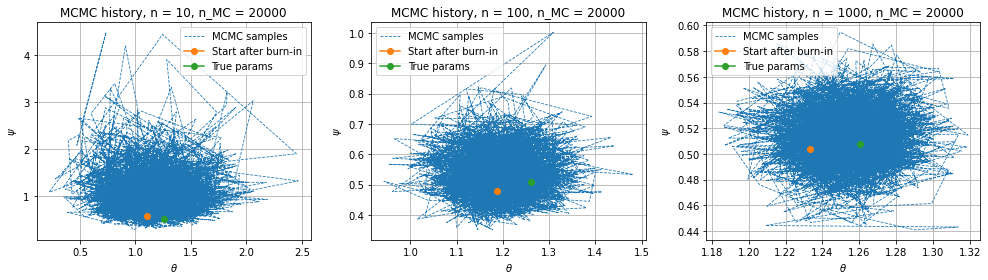

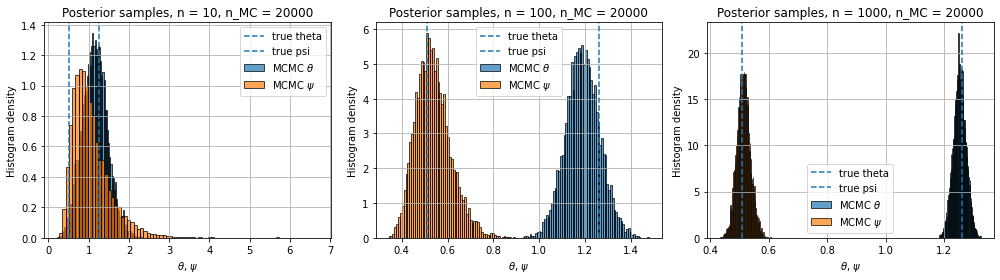

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


rho = 0.5

n_values = [10, 100, 1000]
n_new_samples = 20000
burn_in = 5000

# Proposal standard deviations for log(theta), log(psi)
# Smaller proposal for larger n because posterior is more concentrated
proposal_sds = {
    10: 0.25,
    100: 0.10,
    1000: 0.04
}

# Simulate observations using the same theta_true, psi_true


np.random.seed(44)

X_all = np.random.normal(
    loc=theta_true,
    scale=np.sqrt(psi_true),
    size=1000
)


# Log posterior in log-parameters
# xi = log(theta), gamma = log(psi)

def log_posterior_logparams(xi, gamma, X, rho):
    """
    Log posterior for (xi, gamma) = (log(theta), log(psi)).
    Constants are omitted because MH only needs ratios.
    """

    theta = np.exp(xi)
    psi = np.exp(gamma)

    n = len(X)

    # Likelihood: X_i ~ N(theta, psi)
    sum_squares = np.sum((X - theta)**2)
    log_likelihood = - n / 2 * np.log(psi) - sum_squares / (2 * psi)

    # Prior: (xi, gamma) is bivariate normal with correlation rho
    quad = xi**2 - 2 * rho * xi * gamma + gamma**2
    log_prior = - quad / (2 * (1 - rho**2))

    return log_likelihood + log_prior


# Metropolis-Hastings sampler

def MH_posterior(X, rho, n_new_samples=20000, burn_in=5000, proposal_sd=0.1):
    """
    Random-walk Metropolis-Hastings sampler in log(theta), log(psi).
    Returns samples after burn-in and the acceptance rate.
    """

    total_steps = n_new_samples + burn_in

    # Start from simple data-based values
    theta_start = max(np.mean(X), 1e-6)
    psi_start = max(np.var(X, ddof=1), 1e-6)

    xi = np.log(theta_start)
    gamma = np.log(psi_start)

    current_log_post = log_posterior_logparams(xi, gamma, X, rho)

    samples = []
    accept_count = 0

    for step in range(total_steps):

        # Propose new values in log-scale
        xi_prop = xi + np.random.normal(0, proposal_sd)
        gamma_prop = gamma + np.random.normal(0, proposal_sd)

        prop_log_post = log_posterior_logparams(xi_prop, gamma_prop, X, rho)

        # Acceptance probability
        log_alpha = prop_log_post - current_log_post

        if np.log(np.random.rand()) < log_alpha:
            xi = xi_prop
            gamma = gamma_prop
            current_log_post = prop_log_post
            accept_count += 1

        # Save only after burn-in
        if step >= burn_in:
            theta = np.exp(xi)
            psi = np.exp(gamma)
            samples.append([theta, psi])

    samples = np.array(samples)
    acceptance_rate = accept_count / total_steps

    return samples, acceptance_rate



# Run MH for n = 10, 100, 1000

np.random.seed(45)

posterior_samples = {}
acceptance_rates = {}

for n in n_values:

    X = X_all[:n]

    samples, acc_rate = MH_posterior(
        X=X,
        rho=rho,
        n_new_samples=n_new_samples,
        burn_in=burn_in,
        proposal_sd=proposal_sds[n]
    )

    posterior_samples[n] = samples
    acceptance_rates[n] = acc_rate

    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    print("\n" + "=" * 50)
    print(f"n = {n}")
    print("=" * 50)
    print(f"Acceptance rate: {acc_rate:.4f}")
    print(f"Posterior mean theta: {np.mean(theta_samples):.4f}")
    print(f"Posterior mean psi:   {np.mean(psi_samples):.4f}")
    print(f"True theta:           {theta_true:.4f}")
    print(f"True psi:             {psi_true:.4f}")



# Plot MCMC history in (theta, psi)-space

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))

for k, n in enumerate(n_values):

    samples = posterior_samples[n]

    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    # Plot only every few samples to avoid an overcrowded plot
    plot_step = max(1, len(theta_samples) // 2000)

    ax[k].plot(
        theta_samples[::plot_step],
        psi_samples[::plot_step],
        label="MCMC samples",
        linestyle="dashed",
        linewidth=0.8
    )

    ax[k].plot(
        theta_samples[0],
        psi_samples[0],
        label="Start after burn-in",
        marker="o"
    )

    ax[k].plot(
        theta_true,
        psi_true,
        label="True params",
        marker="o"
    )

    ax[k].set_xlabel(r"$\theta$")
    ax[k].set_ylabel(r"$\psi$")
    ax[k].set_title(f"MCMC history, n = {n}, n_MC = {n_new_samples}")
    ax[k].grid()
    ax[k].legend()

plt.tight_layout()
plt.show()


# Plot posterior histograms for theta and psi

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))

list_nbins = [80, 80, 80]

for k, n in enumerate(n_values):

    samples = posterior_samples[n]

    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    ax[k].hist(
        theta_samples,
        bins=list_nbins[k],
        density=True,
        edgecolor="black",
        alpha=0.7,
        label=r"MCMC $\theta$"
    )

    ax[k].hist(
        psi_samples,
        bins=list_nbins[k],
        density=True,
        edgecolor="black",
        alpha=0.7,
        label=r"MCMC $\psi$"
    )

    ax[k].axvline(
        theta_true,
        linestyle="--",
        label="true theta"
    )

    ax[k].axvline(
        psi_true,
        linestyle="--",
        label="true psi"
    )

    ax[k].set_xlabel(r"$\theta$, $\psi$")
    ax[k].set_ylabel("Histogram density")
    ax[k].set_title(f"Posterior samples, n = {n}, n_MC = {n_new_samples}")
    ax[k].grid()
    ax[k].legend()

plt.tight_layout()
plt.show()